## Setup

Edit config for target dataset as well as labeled sequences

In [18]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import gaussian_kde
from collections import namedtuple

class DSConfig(namedtuple("DSConfig", ["path", "name"])):
    pass

DATASETS_MAP = {
    "confirmed": DSConfig(
        path="data/proteomes/confirmed_candidates/", 
        name="Confirmed Candidates [n=1,074]"
    ),
    "in-silico": DSConfig(
        path="data/proteomes/gnn_predictions/", 
        name="In-Silico Candidates [n=465,872]"
    ),
    "MAPP": DSConfig(
        path="data/test/mass_spec_dedup/",
        name="MAPP Candidates [n=50,251]"
    ),
}

# Config for determining dataset to use.
DATASET = "in-silico"

CONFIG = DATASETS_MAP[DATASET]
# Combined output produced by run_model_inference.py.
# Relative paths resolve from this notebook or the repository root.
MODEL_COMPARISON_RESULT = (
    f"../sequence_to_svm_minimal/{CONFIG.path}"
    "generated/model_comparison_latest.csv"
)

# Displayed at the beginning of every chart title.
DATASET_NAME = CONFIG.name

# sequence -> plot label; matching ignores case and surrounding whitespace.
HIGHLIGHTED_SEQUENCES = {
    # "SLVTKKKRFWCWQRPKYQFL": "DFNA5",
    "SLVTKKKRFWCWQRPKYQFL": "DFNA5",
    "SQLYPRHKHLLIKRSLRCRKC": "DCTN4",
    "MRAKWRKKRMRRLK": "RPL41",
    "RSIFIKYKSKPFCEKLLSWVKS": "PSMG2",
    "SRVPRFYWKDRLLKMKMA": "GLB1",
    "LPLIIFLRNRLKY": "RPS4X",
    "KRRFNIKLWKTF": "PPP1CB",
    "RRYVRKFVLMR": "CHMP2A",
    "SRGLRYYYDKNIIHKTAGKRYVYRFV": "ETS1",
    "GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNM": "RPS29",
}

PLOT_STYLE = "seaborn-v0_8-whitegrid"
N_BINS = 100
plt.style.use(PLOT_STYLE)

# Canonical display names for comparison CSVs that use ESM-/VAE-prefixed labels.
MODEL_ALIASES = {
    "SVM": "SVM",
    "GNN": "GNN",
    "ESM-only": "GNN",
    "VAE-only": "GNN",
    "GNN+QSAR": "GNN+QSAR",
    "GNN+QSAR12": "GNN+QSAR",
    "ESM+QSAR12": "GNN+QSAR",
    "VAE+QSAR12": "GNN+QSAR",
}

# Keep only these models in plots/tables when present (order = display order).
ACTIVE_MODELS = ["SVM", "GNN", "GNN+QSAR"]

_palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
MODEL_COLORS = {
    "SVM": _palette[0],
    "GNN": _palette[1],
    "GNN+QSAR": _palette[2] if len(_palette) > 2 else _palette[0],
}


## Plotting helpers

Safe to ignore after running once to load into notebook

In [19]:
# Plotting helpers


def _normalise_sequence(value):
    if pd.isna(value):
        return ""
    return str(value).strip().upper()


def _highlight_labels():
    if isinstance(HIGHLIGHTED_SEQUENCES, dict):
        items = HIGHLIGHTED_SEQUENCES.items()
    else:
        items = ((sequence, sequence) for sequence in HIGHLIGHTED_SEQUENCES)
    return {
        _normalise_sequence(sequence): str(label)
        for sequence, label in items
        if _normalise_sequence(sequence)
    }


def _resolve_csv_path(value):
    if not str(value).strip():
        raise ValueError("Set MODEL_COMPARISON_RESULT to model_comparison_latest.csv.")

    raw_path = Path(value).expanduser()
    candidates = [raw_path] if raw_path.is_absolute() else [
        Path.cwd() / raw_path,
        Path.cwd() / "notebooks" / raw_path,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(f"Model comparison CSV not found: {raw_path}")


def _find_column(frame, names):
    by_lower = {column.lower(): column for column in frame.columns}
    for name in names:
        if name.lower() in by_lower:
            return by_lower[name.lower()]
    return None


def _add_plot_sequence(frame):
    sequence_col = _find_column(frame, ["sequence", "peptide_sequence", "peptide"])
    id_col = _find_column(frame, ["peptide_id", "id"])
    if sequence_col:
        plot_sequence = frame[sequence_col].map(_normalise_sequence)
    elif id_col:
        plot_sequence = frame[id_col].map(_normalise_sequence)
    else:
        plot_sequence = pd.Series("", index=frame.index, dtype="string")
    frame["__plot_sequence"] = plot_sequence




def _canonical_model_name(model: str) -> str:
    aliases = globals().get("MODEL_ALIASES") or {}
    return aliases.get(model, aliases.get(model.strip(), model))


def _model_sort_key(model: str):
    active = globals().get("ACTIVE_MODELS") or []
    if model in active:
        return (0, active.index(model))
    return (1, model)


def _rename_model_columns(frame: pd.DataFrame) -> pd.DataFrame:
    """Collapse ESM-/VAE-prefixed columns onto SVM / GNN / GNN+QSAR."""
    rename = {}
    for column in frame.columns:
        for suffix in (
            "_pred",
            "_prob_AMP",
            "_confidence",
            "_hyperplane_distance",
            "_distance",
            "_score_z",
            "_logit_AMP",
            "_logit_nonAMP",
            "_logit_margin",
        ):
            if column.endswith(suffix):
                raw_model = column[: -len(suffix)]
                canon = _canonical_model_name(raw_model)
                if canon != raw_model:
                    rename[column] = f"{canon}{suffix}"
                break
    if not rename:
        return frame
    # Prefer already-canonical columns when both exist.
    drop = []
    final_rename = {}
    for src, dst in rename.items():
        if dst in frame.columns and src != dst:
            drop.append(src)
        else:
            final_rename[src] = dst
    out = frame.drop(columns=drop, errors="ignore").rename(columns=final_rename)
    return out


def _progress_prediction_candidates(csv_path: Path) -> list[tuple[str, Path]]:
    progress_dir = csv_path.parent / "compare_progress"
    if not progress_dir.is_dir():
        return []
    found = []
    for path in sorted(progress_dir.glob("*_predictions.csv")):
        stem = path.stem.lower().replace("_predictions", "")
        if "qsar" in stem:
            found.append(("GNN+QSAR", path))
    return found


def _merge_progress_model(frame: pd.DataFrame, model: str, progress_path: Path) -> pd.DataFrame:
    prob_col = f"{model}_prob_AMP"
    if prob_col in frame.columns and frame[prob_col].notna().any():
        return frame
    progress = pd.read_csv(progress_path)
    if "peptide_id" not in progress.columns or "prob_amp" not in progress.columns:
        print(f"Skipping progress file with unexpected columns: {progress_path}")
        return frame
    id_col = _find_column(frame, ["peptide_id", "id"])
    if not id_col:
        return frame

    rename = {"prob_amp": prob_col}
    optional = {
        "pred": f"{model}_pred",
        "logit_amp": f"{model}_logit_AMP",
        "logit_nonamp": f"{model}_logit_nonAMP",
        "logit_margin": f"{model}_logit_margin",
    }
    for src, dst in optional.items():
        if src in progress.columns:
            rename[src] = dst
    keep_cols = ["peptide_id"] + [c for c in rename if c in progress.columns]
    keep = progress[keep_cols].copy()
    keep["peptide_id"] = keep["peptide_id"].astype(str).str.strip()
    keep = keep.drop_duplicates("peptide_id", keep="first").rename(columns=rename)

    merged = frame.copy()
    merged[id_col] = merged[id_col].astype(str).str.strip()
    merged = merged.merge(keep, left_on=id_col, right_on="peptide_id", how="left")
    if id_col != "peptide_id" and "peptide_id" in merged.columns:
        # Drop the right-side merge key only.
        merged = merged.drop(columns=["peptide_id"])
    print(
        f"Merged {model} predictions from {progress_path.name} "
        f"({merged[prob_col].notna().sum():,} / {len(merged):,} rows)"
    )
    return merged


def _filter_active_model_columns(frame: pd.DataFrame) -> pd.DataFrame:
    active = globals().get("ACTIVE_MODELS")
    if not active:
        return frame
    keep = []
    for column in frame.columns:
        if not any(
            column.endswith(suffix)
            for suffix in (
                "_pred",
                "_prob_AMP",
                "_confidence",
                "_hyperplane_distance",
                "_distance",
                "_score_z",
                "_logit_AMP",
                "_logit_nonAMP",
                "_logit_margin",
            )
        ):
            keep.append(column)
            continue
        for suffix in (
            "_pred",
            "_prob_AMP",
            "_confidence",
            "_hyperplane_distance",
            "_distance",
            "_score_z",
            "_logit_AMP",
            "_logit_nonAMP",
            "_logit_margin",
        ):
            if column.endswith(suffix):
                model = column[: -len(suffix)]
                if model in active:
                    keep.append(column)
                break
    return frame.loc[:, keep]

def load_comparison_result():
    csv_path = _resolve_csv_path(MODEL_COMPARISON_RESULT)
    frame = pd.read_csv(csv_path)
    if frame.empty:
        raise ValueError(f"Model comparison CSV is empty: {csv_path}")
    frame = _rename_model_columns(frame)
    for model, progress_path in _progress_prediction_candidates(csv_path):
        frame = _merge_progress_model(frame, model, progress_path)
    frame = _filter_active_model_columns(frame)
    _add_plot_sequence(frame)
    print(f"Loaded {len(frame):,} rows from {csv_path}")
    present = sorted(
        {_model_from_column(c, "_prob_AMP") for c in frame.columns if c.endswith("_prob_AMP")},
        key=_model_sort_key,
    )
    print(f"Active models: {', '.join(present) if present else '(none)'}")
    for model in present:
        col = f"{model}_prob_AMP"
        n_finite = int(pd.to_numeric(frame[col], errors="coerce").notna().sum())
        if n_finite < len(frame):
            print(
                f"  Note: {model} has {n_finite:,}/{len(frame):,} finished predictions "
                f"(partial progress / missing values)."
            )

    prob_columns = sorted(
        [c for c in frame.columns if c.endswith("_prob_AMP")],
        key=lambda c: _model_sort_key(_model_from_column(c, "_prob_AMP")),
    )
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    
    # Assign deterministic colors to any newly discovered models
    next_idx = 0
    for col in prob_columns:
        model = _model_from_column(col, "_prob_AMP")
        if model not in MODEL_COLORS:
            # Find the next color not strictly locked to a model, but avoid infinite loops
            loop_start = next_idx
            while palette[next_idx % len(palette)] in MODEL_COLORS.values() and (next_idx - loop_start) < len(palette):
                next_idx += 1
            color = palette[next_idx % len(palette)]
            MODEL_COLORS[model] = color
            next_idx += 1

    return {"path": csv_path, "frame": frame}


def _model_from_column(column, suffix):
    model = column[: -len(suffix)] if suffix and column.endswith(suffix) else column
    return model.strip("_") or column


def _prob_columns(frame):
    return sorted(
        [column for column in frame.columns if column.endswith("_prob_AMP")],
        key=lambda column: _model_sort_key(_model_from_column(column, "_prob_AMP")),
    )


def _model_pairs(models):
    return [(left, right) for i, left in enumerate(models) for right in models[i + 1 :]]


def _make_entry(dataset, column, suffix, model=None):
    values = pd.to_numeric(dataset["frame"][column], errors="coerce")
    finite = values[np.isfinite(values)]
    if finite.empty:
        return None
    model = model or _model_from_column(column, suffix)
    name = model
    return {
        "name": name,
        "column": column,
        "values": values,
        "finite": finite.to_numpy(dtype=float),
        "frame": dataset["frame"],
    }


def collect_suffix_entries(dataset, suffix):
    entries = []
    for column in dataset["frame"].columns:
        if column.endswith(suffix):
            entry = _make_entry(dataset, column, suffix)
            if entry:
                entries.append(entry)
    entries.sort(key=lambda entry: _model_sort_key(entry["name"]))
    return entries


def collect_raw_score_entries(dataset):
    entries = collect_suffix_entries(dataset, "_logit_margin")
    frame = dataset["frame"]
    distance_col = next(
        (column for column in ("SVM_distance", "SVM_hyperplane_distance") if column in frame),
        None,
    )
    if distance_col:
        entry = _make_entry(dataset, distance_col, "_distance", model="SVM")
        if entry:
            entries.append(entry)
    entries.sort(key=lambda entry: _model_sort_key(entry["name"]))
    return entries


def highlighted_points(entry):
    labels = _highlight_labels()
    if not labels:
        return []
    sequences = entry["frame"]["__plot_sequence"].map(_normalise_sequence)
    points = []
    for sequence, label in labels.items():
        matches = entry["values"].loc[sequences == sequence].dropna()
        matches = matches[np.isfinite(matches)]
        if not matches.empty:
            points.append((float(matches.iloc[0]), label))
    return points


def report_highlight_matches(dataset):
    requested = set(_highlight_labels())
    if not requested:
        return
    observed = set(dataset["frame"]["__plot_sequence"].map(_normalise_sequence))
    missing = requested - observed
    print(f"Highlighted sequences found: {len(requested) - len(missing)}/{len(requested)}")
    if missing:
        print("Not found:", ", ".join(sorted(missing)))


def distribution_xlim(entries, bounded=None):
    values = np.concatenate([entry["finite"] for entry in entries])
    low, high = np.nanpercentile(values, [1, 99])
    highlighted = [x for entry in entries for x, _ in highlighted_points(entry)]
    if highlighted:
        low = min(low, min(highlighted))
        high = max(high, max(highlighted))
    pad = 0.05 * (high - low) if high > low else 1.0
    limits = (float(low - pad), float(high + pad))
    if bounded:
        limits = (max(bounded[0], limits[0]), min(bounded[1], limits[1]))
    return limits


def _kde_counts(values, xs, bin_width, log_y=False):
    if len(values) < 5 or np.unique(values).size < 2:
        return None
    try:
        density = gaussian_kde(values)(xs) * len(values) * bin_width
    except (np.linalg.LinAlgError, ValueError):
        return None
    return np.maximum(density, 1e-6) if log_y else density


def _annotate_highlights(ax, entries, curves, colors, log_y=False):
    annotation_index = 0
    for entry, color in zip(entries, colors):
        xs, ys = curves.get(entry["name"], (None, None))
        for x_value, label in highlighted_points(entry):
            y_value = float(np.interp(x_value, xs, ys)) if xs is not None else 1.0
            if log_y:
                y_value = max(y_value, 1e-3)
            ax.scatter(x_value, y_value, marker="D", s=34, color=color,
                       edgecolor="white", linewidth=0.5, zorder=5)
            side = -1 if annotation_index % 2 else 1
            tier = annotation_index % 4
            ax.annotate(
                label,
                (x_value, y_value),
                xytext=(side * (8 + 4 * tier), 14 + 9 * tier),
                textcoords="offset points",
                ha="left" if side > 0 else "right",
                fontsize=7,
                color=color,
                arrowprops={"arrowstyle": "-", "color": color, "lw": 0.7},
                zorder=6,
            )
            annotation_index += 1


def _model_colors(entries):
    palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    return [
        MODEL_COLORS.get(entry["name"], palette[index % len(palette)])
        for index, entry in enumerate(entries)
    ]


def draw_distribution(ax, entries, title, xlabel, xlim, threshold=None, log_y=False):
    bins = np.linspace(xlim[0], xlim[1], N_BINS + 1)
    bin_width = bins[1] - bins[0]
    xs = np.linspace(xlim[0], xlim[1], 512)
    colors = _model_colors(entries)
    curves = {}

    for entry, color in zip(entries, colors):
        ax.hist(entry["finite"], bins=bins, color=color, edgecolor=color,
                alpha=0.20, linewidth=0.4, zorder=1)
        density = _kde_counts(entry["finite"], xs, bin_width, log_y)
        if density is not None:
            ax.plot(xs, density, color=color, linewidth=2,
                    label=f"{entry['name']} (n={len(entry['finite']):,})", zorder=3)
            curves[entry["name"]] = (xs, density)
        else:
            ax.plot([], [], color=color, linewidth=2,
                    label=f"{entry['name']} (n={len(entry['finite']):,})")

    if threshold is not None:
        ax.axvline(threshold, color="black", linewidth=1, alpha=0.65,
                   label=f"Threshold {threshold:g}", zorder=2)
    ax.set(xlim=xlim, xlabel=xlabel, ylabel="Peptide count", title=title)
    if log_y:
        ax.set_yscale("log")
    _annotate_highlights(ax, entries, curves, colors, log_y)
    ax.legend(loc="best", fontsize=8)


def draw_pairwise_probabilities(fig, axes, dataset):
    frame = dataset["frame"]
    models = [_model_from_column(column, "_prob_AMP") for column in _prob_columns(frame)]
    pairs = _model_pairs(models)
    labels = _highlight_labels()
    sequences = frame["__plot_sequence"].map(_normalise_sequence)
    axes = np.atleast_1d(axes).ravel()

    for ax, (left, right) in zip(axes, pairs):
        x = pd.to_numeric(frame[f"{left}_prob_AMP"], errors="coerce")
        y = pd.to_numeric(frame[f"{right}_prob_AMP"], errors="coerce")
        mask = np.isfinite(x) & np.isfinite(y)
        hb = ax.hexbin(
            x[mask],
            y[mask],
            gridsize=55,
            cmap="viridis",
            mincnt=1,
            bins="log",
            extent=(0, 1, 0, 1),
        )
        ax.plot([0, 1], [0, 1], color="black", linewidth=0.9, alpha=0.55, zorder=3)
        ax.axvline(0.5, color="black", linewidth=0.6, alpha=0.35, zorder=2)
        ax.axhline(0.5, color="black", linewidth=0.6, alpha=0.35, zorder=2)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.set_xlabel(f"{left} P(AMP)")
        ax.set_ylabel(f"{right} P(AMP)")
        ax.set_title(f"{left} vs {right}")
        ax.set_aspect("equal", adjustable="box")

        annotation_index = 0
        for sequence, label in labels.items():
            hit = mask & (sequences == sequence)
            if not bool(hit.any()):
                continue
            ax.scatter(
                x[hit],
                y[hit],
                marker="D",
                s=36,
                color="red",
                edgecolor="white",
                linewidth=0.6,
                zorder=5,
            )
            ax.annotate(
                label,
                (float(x[hit].iloc[0]), float(y[hit].iloc[0])),
                xytext=(6 + 4 * (annotation_index % 3), 10 + 8 * (annotation_index % 3)),
                textcoords="offset points",
                fontsize=7,
                color="red",
            )
            annotation_index += 1
        fig.colorbar(hb, ax=ax, fraction=0.046, pad=0.04, label="log10 count")


## Graphs

Comparison plots for SVM, GNN, and GNN+QSAR prediction analysis

Loaded 465,872 rows from C:\Users\bioin\Documents\Peptide-Anti-microbial-Properties-Prediction\sequence_to_svm_minimal\data\proteomes\gnn_predictions\generated\model_comparison_latest.csv
Active models: SVM, GNN, GNN+QSAR
Highlighted sequences found: 3/10
Not found: GHQQLYWSHPRKFGQGSRSCRVCSNRHGLIRKYGLNM, KRRFNIKLWKTF, MRAKWRKKRMRRLK, RRYVRKFVLMR, SQLYPRHKHLLIKRSLRCRKC, SRGLRYYYDKNIIHKTAGKRYVYRFV, SRVPRFYWKDRLLKMKMA


KeyboardInterrupt: 

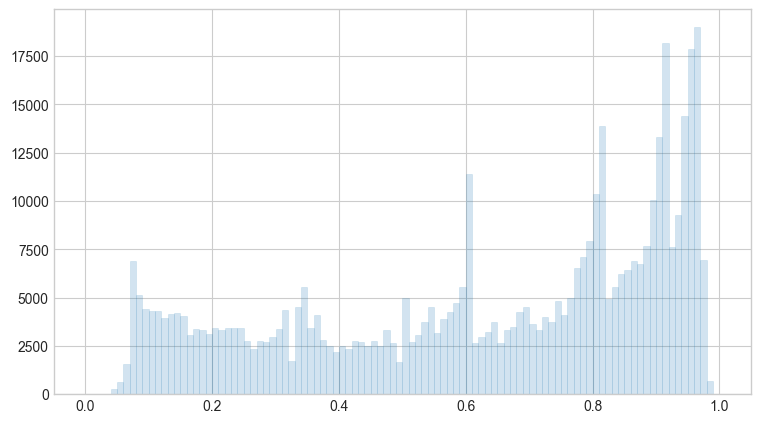

In [20]:
# P(AMP) distributions
comparison_result = load_comparison_result()
report_highlight_matches(comparison_result)
probability_entries = collect_suffix_entries(comparison_result, "_prob_AMP")
if not probability_entries:
    raise ValueError("No finite *_prob_AMP columns were found in the comparison CSV.")
probability_xlim = distribution_xlim(probability_entries, bounded=(0.0, 1.0))

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    probability_entries,
    f"{DATASET_NAME} — P(AMP) distributions",
    "P(AMP)",
    probability_xlim,
    threshold=0.5,
)
fig.tight_layout()
plt.show()


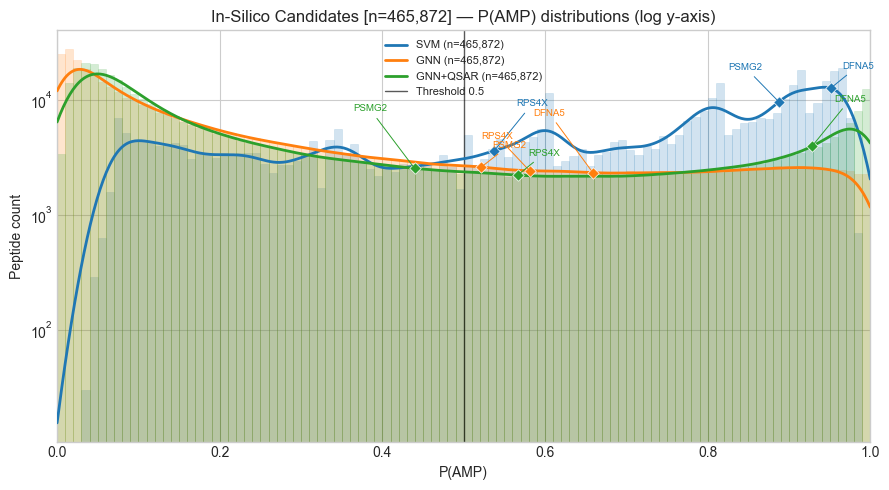

In [ ]:
# P(AMP) distributions with a logarithmic count axis
if "probability_entries" not in globals():
    comparison_result = load_comparison_result()
    probability_entries = collect_suffix_entries(comparison_result, "_prob_AMP")
    probability_xlim = distribution_xlim(probability_entries, bounded=(0.0, 1.0))

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    probability_entries,
    f"{DATASET_NAME} — P(AMP) distributions (log y-axis)",
    "P(AMP)",
    probability_xlim,
    threshold=0.5,
    log_y=True,
)
fig.tight_layout()
plt.show()


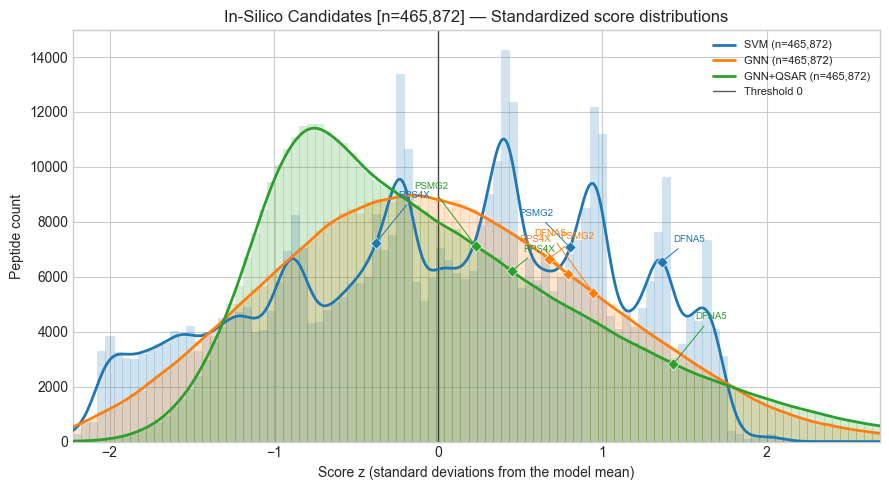

In [ ]:
# Standardized score distributions
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()
standardized_entries = collect_suffix_entries(comparison_result, "_score_z")
if not standardized_entries:
    raise ValueError("No finite *_score_z columns were found in the comparison CSV.")

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    standardized_entries,
    f"{DATASET_NAME} — Standardized score distributions",
    "Score z (standard deviations from the model mean)",
    distribution_xlim(standardized_entries),
    threshold=0.0,
)
fig.tight_layout()
plt.show()


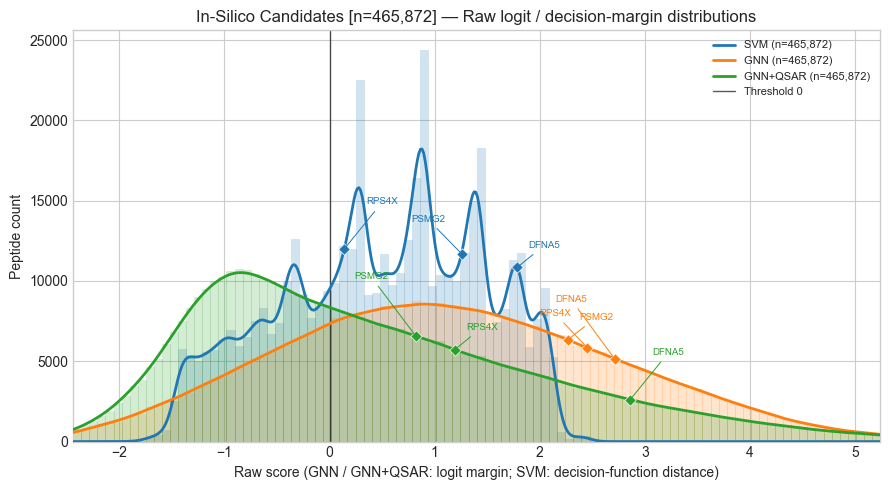

In [ ]:
# Raw logit and decision-margin score distributions
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()
raw_score_entries = collect_raw_score_entries(comparison_result)
if not raw_score_entries:
    raise ValueError("No finite *_logit_margin or SVM distance columns were found.")

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    raw_score_entries,
    f"{DATASET_NAME} — Raw logit / decision-margin distributions",
    "Raw score (GNN / GNN+QSAR: logit margin; SVM: decision-function distance)",
    distribution_xlim(raw_score_entries),
    threshold=0.0,
)
fig.tight_layout()
plt.show()


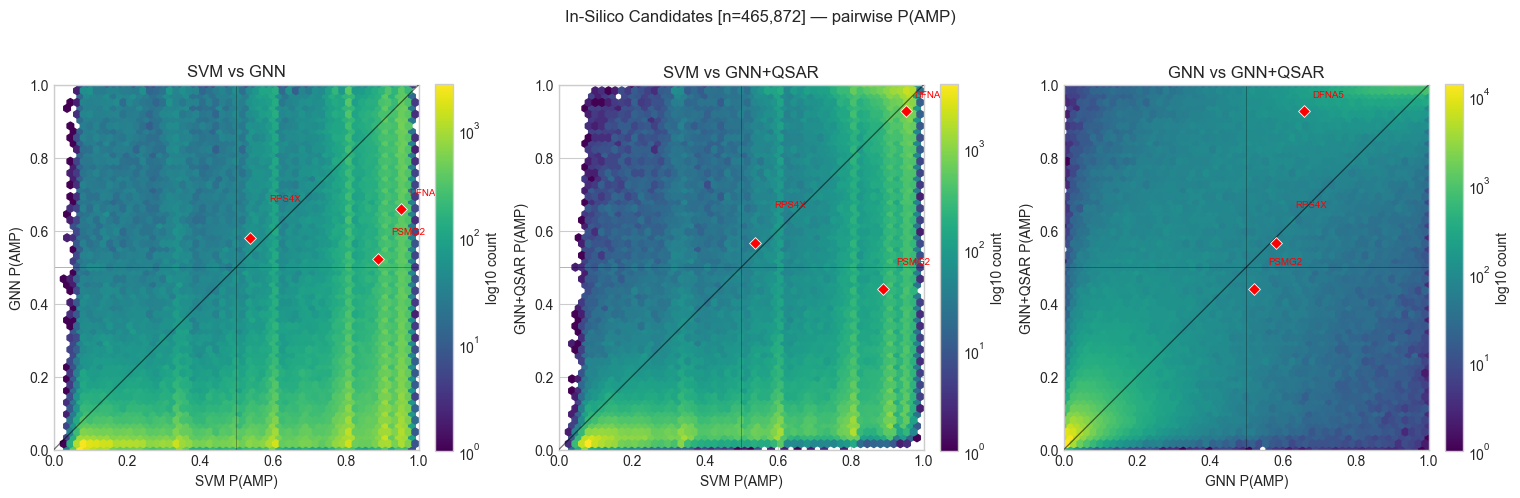

In [ ]:
# Pairwise P(AMP) comparisons, including GNN+QSAR
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
models = [_model_from_column(column, "_prob_AMP") for column in _prob_columns(frame)]
pairs = _model_pairs(models)
if len(pairs) < 1:
    raise ValueError("Need at least two models with P(AMP) columns for pairwise plots.")

n_pairs = len(pairs)
fig, axes = plt.subplots(1, n_pairs, figsize=(5.1 * n_pairs, 4.8), squeeze=False)
draw_pairwise_probabilities(fig, axes, comparison_result)
fig.suptitle(f"{DATASET_NAME} — pairwise P(AMP)", y=1.02)
fig.tight_layout()
plt.show()


## Threshold Analysis

Showing only P(AMP) values from 0.90 to 1.00.


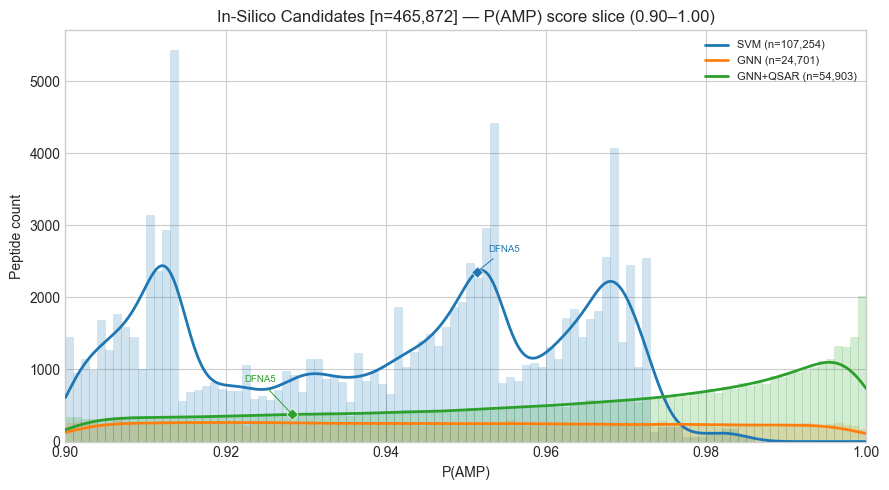

,Model,Candidates in slice,Labeled candidates in slice
0,SVM,107254,1
1,GNN,24701,0
2,GNN+QSAR,54903,1


In [ ]:
# P(AMP) histograms showing only scores within the selected upper slice.
CANDIDATE_PLOT_THRESHOLD = 0.90

if not 0.0 <= CANDIDATE_PLOT_THRESHOLD <= 1.0:
    raise ValueError("CANDIDATE_PLOT_THRESHOLD must be between 0 and 1.")
if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = _prob_columns(frame)
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")
labeled_sequences = set(_highlight_labels())

# Each model contributes only its own scores inside the selected slice.
threshold_probability_entries = []
threshold_counts = []
for column in prob_columns:
    model = column[: -len("_prob_AMP")]
    probabilities = pd.to_numeric(frame[column], errors="coerce")
    passing_frame = frame.loc[probabilities.ge(CANDIDATE_PLOT_THRESHOLD)].copy()
    entry = _make_entry(
        {"path": comparison_result["path"], "frame": passing_frame},
        column,
        "_prob_AMP",
        model=model,
    )
    if entry is not None:
        threshold_probability_entries.append(entry)
    threshold_counts.append(
        {
            "Model": model,
            "Candidates in slice": len(passing_frame),
            "Labeled candidates in slice": passing_frame["__plot_sequence"].isin(
                labeled_sequences
            ).sum(),
        }
    )

if not threshold_probability_entries:
    raise ValueError(
        f"No P(AMP) values are ≥ {CANDIDATE_PLOT_THRESHOLD:.2f} in any model."
    )

# The full chart and its bins represent only this slice; no threshold line is drawn.
threshold_xlim = (CANDIDATE_PLOT_THRESHOLD, 1.0)
print(
    f"Showing only P(AMP) values from {CANDIDATE_PLOT_THRESHOLD:.2f} to 1.00."
)

fig, ax = plt.subplots(figsize=(9, 5))
draw_distribution(
    ax,
    threshold_probability_entries,
    f"{DATASET_NAME} — P(AMP) score slice ({CANDIDATE_PLOT_THRESHOLD:.2f}–1.00)",
    "P(AMP)",
    threshold_xlim,
)
fig.tight_layout()
plt.show()

threshold_candidate_counts = pd.DataFrame(threshold_counts)
display(threshold_candidate_counts)


In [ ]:
# Labeled-sequence threshold summary
from IPython.display import display

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = _prob_columns(frame)
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")

labeled_sequences = _highlight_labels()
if not labeled_sequences:
    raise ValueError("Add sequences to HIGHLIGHTED_SEQUENCES before running this summary.")

summary_rows = []
for normalized_sequence, label in labeled_sequences.items():
    matches = frame.loc[frame["__plot_sequence"] == normalized_sequence]
    if matches.empty:
        row = {
            "Label": label,
            "Sequence": normalized_sequence,
            "Status": "Missing from comparison CSV",
            "Included by any model": False,
        }
        for column in prob_columns:
            model = column[: -len("_prob_AMP")]
            row[f"{model} P(AMP)"] = np.nan
            row[f"{model} included"] = False
        summary_rows.append(row)
        continue

    for _, candidate in matches.iterrows():
        row = {
            "Label": label,
            "Sequence": normalized_sequence,
        }
        included_by_any = False
        for column in prob_columns:
            model = column[: -len("_prob_AMP")]
            score = pd.to_numeric(pd.Series([candidate[column]]), errors="coerce").iloc[0]
            included = bool(pd.notna(score) and score >= CANDIDATE_PLOT_THRESHOLD)
            row[f"{model} P(AMP)"] = score
            row[f"{model} included"] = included
            included_by_any |= included
        row["Included by any model"] = included_by_any
        row["Status"] = "Included" if included_by_any else "Excluded"
        summary_rows.append(row)

labeled_threshold_summary = pd.DataFrame(summary_rows)
status_order = {"Included": 0, "Excluded": 1, "Missing from comparison CSV": 2}
labeled_threshold_summary["__status_order"] = labeled_threshold_summary["Status"].map(status_order)
labeled_threshold_summary = labeled_threshold_summary.sort_values(
    ["__status_order", "Label"], kind="stable"
).drop(columns="__status_order")

status_counts = (
    labeled_threshold_summary["Status"]
    .value_counts()
    .reindex(["Included", "Excluded", "Missing from comparison CSV"], fill_value=0)
)
print(f"Labeled sequences at P(AMP) ≥ {CANDIDATE_PLOT_THRESHOLD:.2f}:")
print(f"  Included by at least one model: {status_counts['Included']}")
print(f"  Excluded by all models:         {status_counts['Excluded']}")
print(f"  Missing from comparison CSV:    {status_counts['Missing from comparison CSV']}")

display_columns = [
    column
    for column in labeled_threshold_summary.columns
    if column not in {"Sequence", "Included by any model", "Status"}
]
display(labeled_threshold_summary[display_columns])

copyable_labeled_threshold_summary = labeled_threshold_summary[display_columns].copy()
for column in copyable_labeled_threshold_summary.columns:
    if column.endswith("P(AMP)"):
        copyable_labeled_threshold_summary[column] = copyable_labeled_threshold_summary[column].map(
            lambda value: "" if pd.isna(value) else f"{value:.4f}"
        )
    elif column.endswith("included") or column == "Included by any model":
        copyable_labeled_threshold_summary[column] = copyable_labeled_threshold_summary[column].map(
            {True: "Yes", False: "No"}
        )

print("\nCopy/paste table:\n")
print(copyable_labeled_threshold_summary.to_string(index=False))


Labeled sequences at P(AMP) ≥ 0.90:
  Included by at least one model: 1
  Excluded by all models:         2
  Missing from comparison CSV:    7


,Label,SVM P(AMP),SVM included,GNN P(AMP),GNN included,GNN+QSAR P(AMP),GNN+QSAR included
0,DFNA5,0.951418,True,0.658790,False,0.928318,True
3,PSMG2,0.887566,False,0.521682,False,0.439557,False
5,RPS4X,0.537567,False,0.580968,False,0.566323,False
7,CHMP2A,NaN,False,NaN,False,NaN,False
1,DCTN4,NaN,False,NaN,False,NaN,False
8,ETS1,NaN,False,NaN,False,NaN,False
4,GLB1,NaN,False,NaN,False,NaN,False
6,PPP1CB,NaN,False,NaN,False,NaN,False
2,RPL41,NaN,False,NaN,False,NaN,False
9,RPS29,NaN,False,NaN,False,NaN,False



Copy/paste table:

 Label SVM P(AMP) SVM included GNN P(AMP) GNN included GNN+QSAR P(AMP) GNN+QSAR included
 DFNA5     0.9514          Yes     0.6588           No          0.9283               Yes
 PSMG2     0.8876           No     0.5217           No          0.4396                No
 RPS4X     0.5376           No     0.5810           No          0.5663                No
CHMP2A                      No                      No                                No
 DCTN4                      No                      No                                No
  ETS1                      No                      No                                No
  GLB1                      No                      No                                No
PPP1CB                      No                      No                                No
 RPL41                      No                      No                                No
 RPS29                      No                      No                                No


## Summary analysis

Candidate counts above **P(AMP) > 0.5** and **P(AMP) > 0.9** for each model, each model's top-10 candidates with cross-model ranks, and a consensus top-10 from the mean of SVM, GNN, and GNN+QSAR ranks.


In [ ]:
# P(AMP) distribution statistics (mean / median / mode / flat zeros)
from IPython.display import display

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = _prob_columns(frame)
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")


def _prob_amp_mode(values: np.ndarray, decimals: int = 4) -> tuple[float, int]:
    """Most frequent P(AMP) after rounding; ties keep the smallest value."""
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return float("nan"), 0
    rounded = np.round(finite.astype(float), decimals)
    uniq, counts = np.unique(rounded, return_counts=True)
    i = int(np.argmax(counts))
    return float(uniq[i]), int(counts[i])


stat_rows = []
for column in prob_columns:
    model = column[: -len("_prob_AMP")]
    probs = pd.to_numeric(frame[column], errors="coerce").to_numpy(dtype=float)
    finite = probs[np.isfinite(probs)]
    n = int(finite.size)
    if n == 0:
        stat_rows.append({
            "Model": model,
            "N": 0,
            "Mean P(AMP)": np.nan,
            "Median P(AMP)": np.nan,
            "Mode P(AMP)": np.nan,
            "Mode count": 0,
            "Flat 0.0": 0,
            "% flat 0.0": np.nan,
        })
        continue
    mode_value, mode_count = _prob_amp_mode(finite)
    n_flat0 = int(np.sum(finite == 0.0))
    stat_rows.append({
        "Model": model,
        "N": n,
        "Mean P(AMP)": float(np.mean(finite)),
        "Median P(AMP)": float(np.median(finite)),
        "Mode P(AMP)": mode_value,
        "Mode count": mode_count,
        "Flat 0.0": n_flat0,
        "% flat 0.0": 100.0 * n_flat0 / n,
    })

prob_stats_table = pd.DataFrame(stat_rows)
copyable_prob_stats = prob_stats_table.copy()
for col in ("Mean P(AMP)", "Median P(AMP)", "Mode P(AMP)"):
    copyable_prob_stats[col] = copyable_prob_stats[col].map(
        lambda x: "" if pd.isna(x) else f"{x:.4f}"
    )
copyable_prob_stats["% flat 0.0"] = copyable_prob_stats["% flat 0.0"].map(
    lambda x: "" if pd.isna(x) else f"{x:.1f}%"
)

display(copyable_prob_stats)
print(
    "Mode = most frequent P(AMP) after rounding to 4 decimals; "
    "Flat 0.0 = exact P(AMP) == 0.0.\n"
)
print("Copyable fixed-width table:\n")
print(
    f"{'Model':<18}{'N':>8}{'Mean':>10}{'Median':>10}"
    f"{'Mode':>10}{'Mode n':>8}{'Flat 0.0':>10}{'% flat 0':>10}"
)
for row in copyable_prob_stats.to_dict("records"):
    print(
        f"{row['Model']:<18}{row['N']:>8,d}{row['Mean P(AMP)']:>10}"
        f"{row['Median P(AMP)']:>10}{row['Mode P(AMP)']:>10}"
        f"{row['Mode count']:>8,d}{row['Flat 0.0']:>10,d}{row['% flat 0.0']:>10}"
    )


,Model,N,Mean P(AMP),Median P(AMP),Mode P(AMP),Mode count,Flat 0.0,% flat 0.0
0,SVM,465872,0.6290,0.7092,0.5000,2979,0,0.0%
1,GNN,465872,0.3078,0.1915,0.0066,377,0,0.0%
2,GNN+QSAR,465872,0.3628,0.2246,0.0378,247,0,0.0%


Mode = most frequent P(AMP) after rounding to 4 decimals; Flat 0.0 = exact P(AMP) == 0.0.

Copyable fixed-width table:

Model                    N      Mean    Median      Mode  Mode n  Flat 0.0  % flat 0
SVM                465,872    0.6290    0.7092    0.5000   2,979         0      0.0%
GNN                465,872    0.3078    0.1915    0.0066     377         0      0.0%
GNN+QSAR           465,872    0.3628    0.2246    0.0378     247         0      0.0%


In [22]:
# Candidate counts above P(AMP) > 0.5 and P(AMP) > 0.9
from IPython.display import display

SUMMARY_THRESHOLDS = (0.5, 0.9)

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"]
prob_columns = _prob_columns(frame)
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")

summary_rows = []
for column in prob_columns:
    model = column[: -len("_prob_AMP")]
    probabilities = pd.to_numeric(frame[column], errors="coerce")
    finite = probabilities.dropna()
    n_finite = len(finite)
    row = {"Model": model, "Finite predictions": n_finite}
    for threshold in SUMMARY_THRESHOLDS:
        passing = int((finite > threshold).sum())
        row[f"P > {threshold:g}"] = passing
        row[f"% P > {threshold:g}"] = (
            100.0 * passing / n_finite if n_finite else 0.0
        )
    summary_rows.append(row)

if len(prob_columns) >= 2:
    prob_frame = pd.DataFrame(
        {
            column[: -len("_prob_AMP")]: pd.to_numeric(frame[column], errors="coerce")
            for column in prob_columns
        }
    )
    all_finite = prob_frame.notna().all(axis=1)
    n_all_finite = int(all_finite.sum())
    all_row = {"Model": "All models", "Finite predictions": n_all_finite}
    for threshold in SUMMARY_THRESHOLDS:
        passing = int((prob_frame > threshold).all(axis=1).sum())
        all_row[f"P > {threshold:g}"] = passing
        all_row[f"% P > {threshold:g}"] = (
            100.0 * passing / n_all_finite if n_all_finite else 0.0
        )
    summary_rows.append(all_row)

summary_table = pd.DataFrame(summary_rows)
copyable_summary_table = summary_table.copy()
for threshold in SUMMARY_THRESHOLDS:
    pct_col = f"% P > {threshold:g}"
    copyable_summary_table[pct_col] = copyable_summary_table[pct_col].map(
        "{:.2f}%".format
    )

display(copyable_summary_table)
print("Copyable fixed-width table:\n")
header = f"{'Model':>12} {'Finite':>12}"
for threshold in SUMMARY_THRESHOLDS:
    header += f" {'P>' + f'{threshold:g}':>12} {'% P>' + f'{threshold:g}':>12}"
print(header)
for row in copyable_summary_table.to_dict("records"):
    line = f"{row['Model']:>12} {row['Finite predictions']:>12,d}"
    for threshold in SUMMARY_THRESHOLDS:
        line += (
            f" {row[f'P > {threshold:g}']:>12,d}"
            f" {row[f'% P > {threshold:g}']:>12}"
        )
    print(line)


,Model,Finite predictions,P > 0.5,% P > 0.5,P > 0.9,% P > 0.9
0,SVM,465872,315651,67.75%,107254,23.02%
1,GNN,465872,121095,25.99%,24701,5.30%
2,GNN+QSAR,465872,149054,31.99%,54903,11.78%
3,All models,465872,85094,18.27%,7034,1.51%


Copyable fixed-width table:

       Model       Finite        P>0.5      % P>0.5        P>0.9      % P>0.9
         SVM      465,872      315,651       67.75%      107,254       23.02%
         GNN      465,872      121,095       25.99%       24,701        5.30%
    GNN+QSAR      465,872      149,054       31.99%       54,903       11.78%
  All models      465,872       85,094       18.27%        7,034        1.51%


In [ ]:
# Top-10 candidates per model
from IPython.display import display

TOP_N = 10

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()

frame = comparison_result["frame"].copy()
prob_columns = _prob_columns(frame)
if not prob_columns:
    raise ValueError("No *_prob_AMP columns were found in the comparison CSV.")

models = [c[: -len("_prob_AMP")] for c in prob_columns]
seq_col = _find_column(frame, ["sequence", "peptide_sequence", "peptide"])
if not seq_col:
    raise ValueError("No sequence column was found in the comparison CSV.")

for column, model in zip(prob_columns, models):
    frame[f"__{model}_prob"] = pd.to_numeric(frame[column], errors="coerce")

print(f"Top {TOP_N} candidates per model (highest P(AMP) first):\n")
for model in models:
    others = [other for other in models if other != model]
    ranked = frame.dropna(subset=[f"__{model}_prob"]).sort_values(
        f"__{model}_prob", ascending=False, kind="mergesort"
    ).head(TOP_N)
    rows = []
    for _, row in ranked.iterrows():
        out = {
            "sequence": row[seq_col],
            f"{model} P(AMP)": float(row[f"__{model}_prob"]),
        }
        for other in others:
            other_prob = row[f"__{other}_prob"]
            out[f"{other} P(AMP)"] = (
                float(other_prob) if pd.notna(other_prob) else float("nan")
            )
        rows.append(out)
    model_view = pd.DataFrame(rows)
    for column in model_view.columns:
        if column.endswith("P(AMP)"):
            model_view[column] = model_view[column].map(
                lambda value: "" if pd.isna(value) else f"{value:.4f}"
            )
    print(f"=== Top {TOP_N} by {model} ===")
    display(model_view)
    print(model_view.to_string(index=False))
    print()


Top 10 candidates per model (highest P(AMP) first):

=== Top 10 by SVM ===


,sequence,SVM P(AMP),GNN P(AMP),GNN+QSAR P(AMP)
0,RLLRRGLWNLAARTCCLFQNSVIASRARKTLTADKLEHLKSQL,0.9853,0.5629,0.8866
1,LLSLYKFFAPALISVSLPVRKKIYFKNSENLWKTALLAVKQRNR,0.9852,0.4615,0.9516
2,KALNRCQLKHTIALWQFLSAHKSEQLLRLHKEPFGEISSRYK,0.9852,0.4654,0.7492
3,KVVLESPWPSSTRSGIFLWTKVRNVVRGLAQFRQPLKKTVQR,0.9852,0.1089,0.2276
4,KRSSFFIKIRPGEQEQYESTIGFKLPSYRAAKKLWKVCVEHHTFFRL,0.9852,0.4128,0.8941
5,ALAQIPQKVLWRFDGKKPNTLGSNTRLYKWLPQNDLLGHPKTKAFITH,0.9852,0.3292,0.9101
6,RGSRLWCSQKSGGVSRDWIGVPRKLYKPGAKEPRCVCVR,0.9851,0.8958,0.9143
7,RSGNYLWHGHLRLKEHIDRKFVPFRKLQFGRYPGAFDRPELQQVTV,0.9851,0.4954,0.8176
8,RPPAVCSHFTQNLWTVQGIEDSFHKLIPKGHEKRGHENLRKTCKSI,0.9851,0.6601,0.9082
9,VPVGIPAASQRIFLHGNRISHVPAASFRACRNLTILWLHSNVLARI,0.9851,0.3830,0.8596


                                        sequence SVM P(AMP) GNN P(AMP) GNN+QSAR P(AMP)
     RLLRRGLWNLAARTCCLFQNSVIASRARKTLTADKLEHLKSQL     0.9853     0.5629          0.8866
    LLSLYKFFAPALISVSLPVRKKIYFKNSENLWKTALLAVKQRNR     0.9852     0.4615          0.9516
      KALNRCQLKHTIALWQFLSAHKSEQLLRLHKEPFGEISSRYK     0.9852     0.4654          0.7492
      KVVLESPWPSSTRSGIFLWTKVRNVVRGLAQFRQPLKKTVQR     0.9852     0.1089          0.2276
 KRSSFFIKIRPGEQEQYESTIGFKLPSYRAAKKLWKVCVEHHTFFRL     0.9852     0.4128          0.8941
ALAQIPQKVLWRFDGKKPNTLGSNTRLYKWLPQNDLLGHPKTKAFITH     0.9852     0.3292          0.9101
         RGSRLWCSQKSGGVSRDWIGVPRKLYKPGAKEPRCVCVR     0.9851     0.8958          0.9143
  RSGNYLWHGHLRLKEHIDRKFVPFRKLQFGRYPGAFDRPELQQVTV     0.9851     0.4954          0.8176
  RPPAVCSHFTQNLWTVQGIEDSFHKLIPKGHEKRGHENLRKTCKSI     0.9851     0.6601          0.9082
  VPVGIPAASQRIFLHGNRISHVPAASFRACRNLTILWLHSNVLARI     0.9851     0.3830          0.8596

=== Top 10 by GNN ===


,sequence,GNN P(AMP),SVM P(AMP),GNN+QSAR P(AMP)
0,RRRCFRGFGRRV,0.9999,0.8780,0.9960
1,LGRWRRKRRWR,0.9999,0.9499,0.9956
2,RRLWPCGRRRRH,0.9999,0.9166,0.9544
3,CRRRRRRRPLWRV,0.9999,0.8906,0.9811
4,RWCGRRRLRWRL,0.9999,0.9532,0.9975
5,RGCPLLRRWLCRR,0.9998,0.9125,0.9953
6,RRLLCRCGRRL,0.9998,0.8631,0.9907
7,MGRRCCRRRVL,0.9998,0.1252,0.7700
8,GSFLRRRRRF,0.9998,0.8900,0.9948
9,SLLRCVRRRRRRHRRCRRRCC,0.9998,0.8527,1.0000


             sequence GNN P(AMP) SVM P(AMP) GNN+QSAR P(AMP)
         RRRCFRGFGRRV     0.9999     0.8780          0.9960
          LGRWRRKRRWR     0.9999     0.9499          0.9956
         RRLWPCGRRRRH     0.9999     0.9166          0.9544
        CRRRRRRRPLWRV     0.9999     0.8906          0.9811
         RWCGRRRLRWRL     0.9999     0.9532          0.9975
        RGCPLLRRWLCRR     0.9998     0.9125          0.9953
          RRLLCRCGRRL     0.9998     0.8631          0.9907
          MGRRCCRRRVL     0.9998     0.1252          0.7700
           GSFLRRRRRF     0.9998     0.8900          0.9948
SLLRCVRRRRRRHRRCRRRCC     0.9998     0.8527          1.0000

=== Top 10 by GNN+QSAR ===


,sequence,GNN+QSAR P(AMP),SVM P(AMP),GNN P(AMP)
0,RRRHCSRRRLHRIHRRQHRSCRRRKRRSCRHRRRHRRGCRTRKRTCRRH,1.0000,0.2965,0.9995
1,GQSHYRRRHCSRRRLHRIHRRQHRSCRRRKRRSCRHRRRHR,1.0000,0.5893,0.9979
2,RRRLHRIHRRQHRSCRRRKRRSCRHRRRHRRGCRTR,1.0000,0.7495,0.9996
3,QHRSCRRRKRRSCRHRRRHRRGCRTRKRTCRRH,1.0000,0.8486,0.9993
4,KLTHLRKRIHRPRRRTTRRWKRWFKFRKRKGEKRPRPNHKAVARRA...,1.0000,0.7100,0.9234
5,RGKKKKKKSTRKKRRRSSSYSPSPVKKKKKKSSKKHKRRRSFSKKRRH,1.0000,0.2263,0.6886
6,RSNGKWDRPQIVCTKPRRSHRMRRHHHHHQHHHQHHHHKSRKERRK...,1.0000,0.5000,0.8158
7,RHCSRRRLHRIHRRQHRSCRRRKRRSCRHR,1.0000,0.8518,0.9992
8,AVRSRSRTHSRSRSRSPRKRRSRSRSGSRKRKHRKRSRSRSRERKR...,1.0000,0.3709,0.9571
9,RSRSPLRRSRSPRRRSRSPRRRDRGRRSRSRLRRRSRSRGGRRRRS...,1.0000,0.7022,0.9725


                                          sequence GNN+QSAR P(AMP) SVM P(AMP) GNN P(AMP)
 RRRHCSRRRLHRIHRRQHRSCRRRKRRSCRHRRRHRRGCRTRKRTCRRH          1.0000     0.2965     0.9995
         GQSHYRRRHCSRRRLHRIHRRQHRSCRRRKRRSCRHRRRHR          1.0000     0.5893     0.9979
              RRRLHRIHRRQHRSCRRRKRRSCRHRRRHRRGCRTR          1.0000     0.7495     0.9996
                 QHRSCRRRKRRSCRHRRRHRRGCRTRKRTCRRH          1.0000     0.8486     0.9993
KLTHLRKRIHRPRRRTTRRWKRWFKFRKRKGEKRPRPNHKAVARRAKLKF          1.0000     0.7100     0.9234
  RGKKKKKKSTRKKRRRSSSYSPSPVKKKKKKSSKKHKRRRSFSKKRRH          1.0000     0.2263     0.6886
RSNGKWDRPQIVCTKPRRSHRMRRHHHHHQHHHQHHHHKSRKERRKHKKH          1.0000     0.5000     0.8158
                    RHCSRRRLHRIHRRQHRSCRRRKRRSCRHR          1.0000     0.8518     0.9992
AVRSRSRTHSRSRSRSPRKRRSRSRSGSRKRKHRKRSRSRSRERKRKSSR          1.0000     0.3709     0.9571
RSRSPLRRSRSPRRRSRSPRRRDRGRRSRSRLRRRSRSRGGRRRRSRSKV          1.0000     0.7022     0.9725



In [ ]:
# Top-10 by mean rank across SVM, GNN, and GNN+QSAR (VAE+QSAR)
from IPython.display import display

TOP_N = 10
RANK_MODELS = ["SVM", "GNN", "GNN+QSAR"]
RANK_WEIGHTS = {model: 1.0 for model in RANK_MODELS}

if "comparison_result" not in globals():
    comparison_result = load_comparison_result()


def _rank_from_prob(probs: pd.Series) -> pd.Series:
    return pd.to_numeric(probs, errors="coerce").rank(ascending=False, method="min")


def _weighted_mean_rank(ranks: pd.DataFrame, models: list[str], weights: dict[str, float]) -> pd.Series:
    weight_sum = sum(weights[model] for model in models)
    if weight_sum <= 0:
        raise ValueError("RANK_WEIGHTS must sum to a positive value.")
    combined = sum(weights[model] * ranks[model] for model in models)
    return combined / weight_sum


frame = comparison_result["frame"].copy()
id_col = _find_column(frame, ["peptide_id", "id"])
seq_col = _find_column(frame, ["sequence", "peptide_sequence", "peptide"])
labels = _highlight_labels()

missing = [model for model in RANK_MODELS if f"{model}_prob_AMP" not in frame.columns]
if missing:
    raise ValueError(f"Missing P(AMP) columns for: {', '.join(missing)}")

ranks = pd.DataFrame({
    model: _rank_from_prob(frame[f"{model}_prob_AMP"])
    for model in RANK_MODELS
})
probs = pd.DataFrame({
    model: pd.to_numeric(frame[f"{model}_prob_AMP"], errors="coerce")
    for model in RANK_MODELS
})
complete = ranks.dropna()
mean_rank = _weighted_mean_rank(complete, RANK_MODELS, RANK_WEIGHTS)

ranked_index = mean_rank.sort_values(kind="mergesort").head(TOP_N).index
weight_label = " + ".join(
    f"{RANK_WEIGHTS[model]:g}·{model}" for model in RANK_MODELS
)

rows = []
for position, idx in enumerate(ranked_index, start=1):
    row = frame.loc[idx]
    sequence = _normalise_sequence(row[seq_col]) if seq_col else ""
    out = {
        "Consensus rank": position,
        "peptide_id": row[id_col] if id_col else "",
        "sequence": row[seq_col] if seq_col else "",
        "Label": labels.get(sequence, ""),
        "Mean rank": float(mean_rank.loc[idx]),
    }
    for model in RANK_MODELS:
        out[f"{model} P(AMP)"] = float(probs.loc[idx, model])
        out[f"{model} rank"] = int(ranks.loc[idx, model])
    rows.append(out)

top10_mean_rank = pd.DataFrame(rows)
copyable_mean_rank = top10_mean_rank.copy()
copyable_mean_rank["Mean rank"] = copyable_mean_rank["Mean rank"].map("{:.1f}".format)
for model in RANK_MODELS:
    copyable_mean_rank[f"{model} P(AMP)"] = copyable_mean_rank[f"{model} P(AMP)"].map(
        lambda x: "" if pd.isna(x) else f"{x:.4f}"
    )

print(
    f"Top {TOP_N} by weighted mean rank ({weight_label}; "
    "rank 1 = highest P(AMP) for each model). "
    "GNN+QSAR is the VAE+QSAR model.\n"
)
display(copyable_mean_rank)
print(copyable_mean_rank.to_string(index=False))


Top 10 by weighted mean rank (1·SVM + 1·GNN + 1·GNN+QSAR; rank 1 = highest P(AMP) for each model). GNN+QSAR is the VAE+QSAR model.



,Consensus rank,peptide_id,sequence,Label,Mean rank,SVM P(AMP),SVM rank,GNN P(AMP),GNN rank,GNN+QSAR P(AMP),GNN+QSAR rank
0,1,PEP_40497,RRVFGRIRRFFSRRR,,1076.0,0.9729,1640,0.9997,25,0.9993,1563
1,2,PEP_123945,RRLRRRPRGLRCSRL,,1751.3,0.9729,1640,0.9996,41,0.9979,3573
2,3,PEP_36246,SLRLRRRHRCGGSLLSRRWVL,,1882.0,0.9728,2560,0.9938,1381,0.9992,1705
3,4,PEP_61939,RSLRRRVRRLRRL,,1894.0,0.9717,4517,0.9996,44,0.9995,1121
4,5,PEP_39077,RLSVSRWHRRRGVGRRLLAF,,1942.3,0.9729,1640,0.9940,1335,0.9985,2852
5,6,PEP_112978,RFHLHLRRHRRI,,2059.3,0.9715,4711,0.9962,817,0.9998,650
6,7,PEP_5108,RALRFLLGRLPWRVASGARRFRRW,,2065.3,0.9728,2379,0.9979,429,0.9981,3388
7,8,PEP_121282,KHPGLLLILGKLILLHHKHPERKQ,,2227.7,0.9728,2379,0.9904,2179,0.9989,2125
8,9,PEP_126434,QHFRRSLRHIFRRR,,2309.3,0.9726,2911,0.9986,276,0.9978,3741
9,10,PEP_224746,AYKFAKNHAKLGLKEVKSKLKH,,2575.0,0.9725,3252,0.9865,3051,0.9993,1422


 Consensus rank peptide_id                 sequence Label Mean rank SVM P(AMP)  SVM rank GNN P(AMP)  GNN rank GNN+QSAR P(AMP)  GNN+QSAR rank
              1  PEP_40497          RRVFGRIRRFFSRRR          1076.0     0.9729      1640     0.9997        25          0.9993           1563
              2 PEP_123945          RRLRRRPRGLRCSRL          1751.3     0.9729      1640     0.9996        41          0.9979           3573
              3  PEP_36246    SLRLRRRHRCGGSLLSRRWVL          1882.0     0.9728      2560     0.9938      1381          0.9992           1705
              4  PEP_61939            RSLRRRVRRLRRL          1894.0     0.9717      4517     0.9996        44          0.9995           1121
              5  PEP_39077     RLSVSRWHRRRGVGRRLLAF          1942.3     0.9729      1640     0.9940      1335          0.9985           2852
              6 PEP_112978             RFHLHLRRHRRI          2059.3     0.9715      4711     0.9962       817          0.9998            650
             